# 02 — 第一代：Heuristic Filtering

**方法论定位（第一代）**：人工设计规则，按 FineWeb 实际过滤顺序执行。

过滤顺序：URL → 语言 → Gopher质量 → C4质量 → FineWeb质量 → 重复 → PII脱敏 → 毒性

**本代的核心价值和局限**：
- 可解释、极快、不需要训练
- 能过滤"明显的垃圾"（乱码、广告、模板）
- 无法区分"平庸内容"和"高质量内容"（都能通过规则）
- 规则之间无协同，阈值靠经验

> 本 notebook 读取 pipeline 预计算结果（`data/gen1_output/`），不再逐步运行过滤器。
> Pipeline 脚本：`scripts/run_gen1.py`

## A. URL 过滤

**原理**：在文本提取之前，基于 URL 字符串本身过滤明显的垃圾域名。

成本极低（只检查 URL），可以在 WARC 读取阶段就剔除，节省后续 Trafilatura 提取的计算量。

## B. 语言过滤

**原理**：使用 fastText langid 模型（支持 176 种语言）识别文档语言。

Common Crawl 中非英文文档约占 50-60%（对于英文 pipeline）。语言过滤是保证训练数据纯净度最基础的步骤。

**技术选型**：fastText langid > langdetect > cld3
- fastText langid 速度极快（微秒级/文档）
- 在短文本上精度优于其他方案
- FineWeb 和 DCLM 都用 fastText langid

## C. Gopher 质量过滤

**规则来源**：DeepMind Gopher 论文（2021）

6条核心规则，检测"明显的低质量"：
1. 文档长度（50-100000词）
2. 平均句子长度（3-1000词）
3. 字母字符占比（>70%）
4. 停用词数量（至少2个英文停用词）
5. 省略号行比例（<30%）
6. 非字母开头词比例（<20%）

## D. 内容安全过滤（毒性过滤）

> **内容安全分类是多级体系，不是"有毒/无毒"二分类**
>
> 工业级实践按**类型**（色情/暴力/仇恨/自残等）和**严重程度**（轻微/中度/严重）分级。不同类型策略不同：
> - **严重暴力、仇恨言论**：完全过滤
> - **模糊边界内容（医学/历史/新闻）**：标记但保留
> - **轻微冒犯性语言**：可改写脱敏
>
> **与 TikTok 内容安全审核的对应关系**：
> 预训练数据过滤 = 机器初筛（高阈值，宁可多杀不能漏）。
> 产品层面的内容审核 = 多级人机协同（机器粗筛 → 人工复核 → 申诉机制）。
> 两者的目标不同，阈值设置逻辑也不同。
>
> **Precision-Recall 困境**：
> - 阈值 0.5：过滤 X%，但医学文本/新闻报道可能被误杀
> - 阈值 0.85：漏杀率高，但误杀率低
> - 阈值 0.95：极保守，几乎只过滤最明显的有害内容
>
> 没有完美阈值，只有根据场景做的 trade-off。

In [1]:
# === Cell A: 环境初始化 + 数据加载 ===
# 读取 pipeline 预计算结果，不再逐步运行过滤器
# 数据来源：scripts/run_gen1.py 的输出
import sys
sys.path.insert(0, '..')
import json
import random
import numpy as np
from pathlib import Path
from src.utils.config_loader import load_run_config, print_config_summary

run_cfg = load_run_config()
print_config_summary(run_cfg)

# --- 加载 pipeline 统计数据 ---
stats_path = Path('../data/gen1_output/gen1_pipeline_stats.json')
with open(stats_path) as f:
    pipeline_data = json.load(f)

pipeline_stats = pipeline_data['pipeline_stats']
input_count = pipeline_data['input_count']
output_count = pipeline_data['output_count']
retention_rate = pipeline_data['retention_rate']

print(f"Pipeline 统计数据已加载: {stats_path}")
print(f"  输入: {input_count:,} 条 | 输出: {output_count:,} 条 | 保留率: {retention_rate:.1%}")

# --- 加载原始文档样本 ---
raw_dir = Path('../data/raw')
raw_docs = []
jsonl_files = list(raw_dir.glob('*.jsonl'))
if jsonl_files:
    with open(jsonl_files[0]) as f:
        for i, line in enumerate(f):
            if i >= run_cfg['doc_limit']:
                break
            try:
                raw_docs.append(json.loads(line))
            except Exception:
                pass
print(f"原始文档加载: {len(raw_docs):,} 条")

# --- 加载 gen1 输出文档样本 ---
output_path = Path('../data/gen1_output/gen1_output.jsonl')
gen1_docs = []
with open(output_path) as f:
    for line in f:
        try:
            gen1_docs.append(json.loads(line))
        except Exception:
            pass
print(f"Gen1 输出文档加载: {len(gen1_docs):,} 条")

  当前运行模式: MEDIUM_RUN
  20-30分钟跑完，产出有统计意义的对比数据
──────────────────────────────────────────────────
  doc_limit       : 12,000
  eval_sample_size: 500
  audit_sample_size: 50
  rewrite_count   : 100
  random_seed     : 42
Pipeline 统计数据已加载: ../data/gen1_output/gen1_pipeline_stats.json
  输入: 12,000 条 | 输出: 409 条 | 保留率: 3.4%


原始文档加载: 12,000 条
Gen1 输出文档加载: 409 条


In [2]:
# === Cell B: 逐阶段统计表 ===
# 展示 pipeline 各阶段的文档数、过滤数和过滤率

# 阶段名称中英文映射
step_names = {
    'url_filter': 'URL 过滤',
    'language_filter': '语言过滤',
    'quality_filter': '质量过滤 (Gopher+C4+FineWeb)',
    'repetition_filter': '重复过滤',
    'pii_filter': 'PII 脱敏',
    'toxicity_filter': '毒性过滤',
}

print("=" * 72)
print(f"{'阶段':<30} {'输入':>8} {'输出':>8} {'过滤':>8} {'过滤率':>10}")
print("-" * 72)
for s in pipeline_stats:
    name = step_names.get(s['step'], s['step'])
    print(f"{name:<30} {s['before']:>8,} {s['after']:>8,} "
          f"{s['filtered']:>8,} {s['filter_rate']:>9.1%}")
print("-" * 72)
print(f"{'总计':<30} {input_count:>8,} {output_count:>8,} "
      f"{input_count - output_count:>8,} {1 - retention_rate:>9.1%}")
print("=" * 72)
print(f"\n总保留率: {retention_rate:.1%} ({output_count:,} / {input_count:,})")

阶段                                   输入       输出       过滤        过滤率
------------------------------------------------------------------------
url_dedup                        12,000   11,997        3      0.0%
URL 过滤                           11,997   11,851      146      1.2%
语言过滤                             11,851    2,912    8,939     75.4%
质量过滤 (Gopher+C4+FineWeb)          2,912      832    2,080     71.4%
重复过滤                                832      409      423     50.8%
PII 脱敏                              409      409        0      0.0%
------------------------------------------------------------------------
总计                               12,000      409   11,591     96.6%

总保留率: 3.4% (409 / 12,000)


In [3]:
# === Cell C: 样本文本对比 ===
# 展示原始输入 vs gen1 输出的文本样例
# 被过滤的文档 = 在原始数据中但不在输出中的文档（通过 URL 匹配）

random.seed(42)

# 构建 gen1 输出 URL 集合用于快速查找
gen1_urls = set(d.get('url', '') for d in gen1_docs)

# 找出被过滤掉的文档（在原始数据中但不在输出中）
filtered_docs = [d for d in raw_docs if d.get('url', '') not in gen1_urls]

print("=" * 70)
print("  被过滤掉的文档样例（3 条）")
print("=" * 70)
sample_filtered = random.sample(filtered_docs, min(3, len(filtered_docs)))
for i, d in enumerate(sample_filtered, 1):
    print(f"\n[过滤 {i}] URL: {d.get('url', 'N/A')[:80]}")
    text_preview = d.get('text', '')[:250].replace('\n', ' ')
    print(f"  文本前 250 字: {text_preview!r}")

print("\n" + "=" * 70)
print("  通过过滤的文档样例（3 条）")
print("=" * 70)
sample_passed = random.sample(gen1_docs, min(3, len(gen1_docs)))
for i, d in enumerate(sample_passed, 1):
    print(f"\n[通过 {i}] URL: {d.get('url', 'N/A')[:80]}")
    text_preview = d.get('text', '')[:250].replace('\n', ' ')
    print(f"  文本前 250 字: {text_preview!r}")

  被过滤掉的文档样例（3 条）

[过滤 1] URL: http://kalugates.ru/rybalka/korrektivy-zakona-o-gee-proshli-pervoe-chtenie.html
  文本前 250 字: 'Коррективы закона о ГЭЭ прошли первое чтение - Kaluga Hunt-Fish. Перейти к содержанию Kaluga Hunt-Fish. Охота и Рыбалка: информационный портал. Охота Рыбалка Оружие Фото Кухня Туризм Экология Карта сайта Найти: Главное Меню Рыбалка Коррективы закона '

[过滤 2] URL: http://andreuccitorrejonabogados.cl/
  文本前 250 字: 'One moment, please... Please wait while your request is being verified...'

[过滤 3] URL: http://drvdavphillaur.com/Event-Calendar
  文本前 250 字: '\u200bDRV DAV Centenary Public School,\u200b Phillaur (Distt. Jalandhar) ABOUT DAVCMC ARYA SAMAJ PRESIDENT’s MESSAGE DAVCMC VIDEOS ALUMNI DAVCMC INTELLECTUAL HUB \u200bDRV DAV Centenary Public School,PHILLAUR Distt Jalandhar (Punjab) Affiliated to CBSE, New Delhi H'

  通过过滤的文档样例（3 条）

[通过 1] URL: http://foodgovernance.com/agroecology-at-the-committee-on-world-food-security/
  文本前 250 字: 'Food Governance | Agroecol

/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_41219/1791361375.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_41219/1791361375.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9)


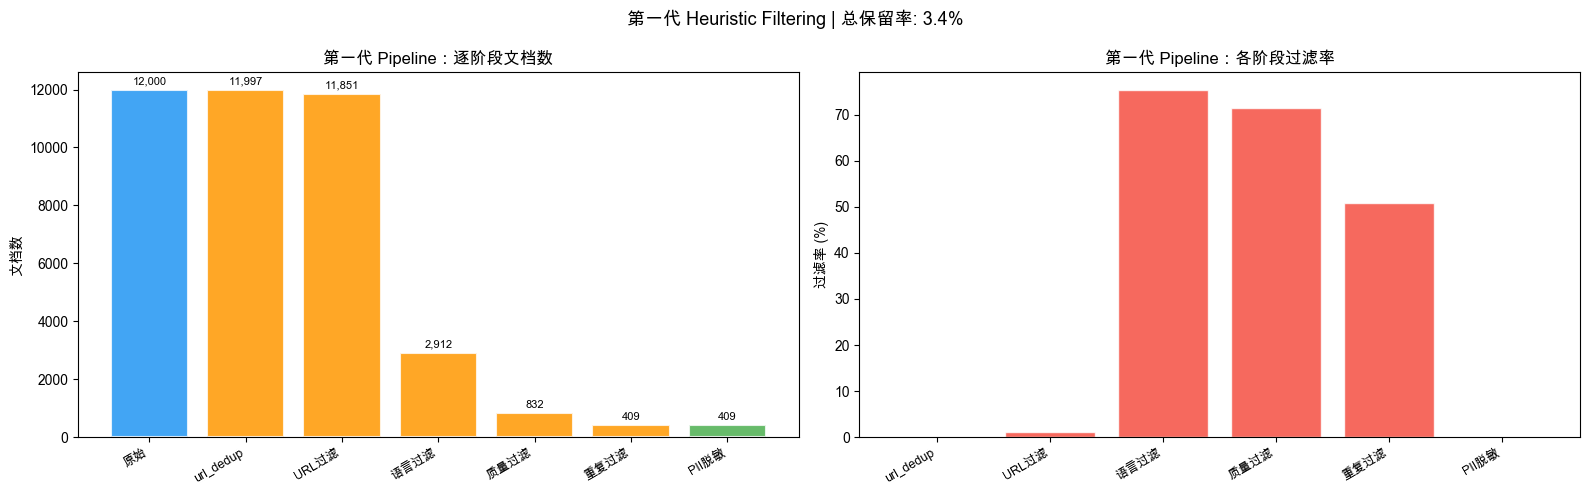

In [4]:
# === Cell D: 瀑布图可视化 ===
# 左图：文档数瀑布图（蓝=原始，橙=中间阶段，绿=最终输出）
# 右图：各阶段过滤率，直观对比哪个阶段过滤最多
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 构建阶段序列（含"原始输入"）
step_names_ordered = {
    'url_filter': 'URL过滤',
    'language_filter': '语言过滤',
    'quality_filter': '质量过滤',
    'repetition_filter': '重复过滤',
    'pii_filter': 'PII脱敏',
    'toxicity_filter': '毒性过滤',
}

stages = ['原始']
counts = [input_count]
filter_rates = [0.0]

for s in pipeline_stats:
    label = step_names_ordered.get(s['step'], s['step'])
    stages.append(label)
    counts.append(s['after'])
    filter_rates.append(s['filter_rate'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- 左图：文档数瀑布 ---
colors = ['#2196F3' if i == 0
          else '#4CAF50' if i == len(counts) - 1
          else '#FF9800'
          for i in range(len(counts))]
bars = ax1.bar(stages, counts, color=colors, alpha=0.85,
               edgecolor='white', linewidth=1.5)
ax1.set_ylabel('文档数')
ax1.set_title('第一代 Pipeline：逐阶段文档数', fontweight='bold')
ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(counts) * 0.01,
             f'{count:,}', ha='center', va='bottom', fontsize=8)

# --- 右图：逐阶段过滤率 ---
ax2.bar(stages[1:], [r * 100 for r in filter_rates[1:]],
        color='#f44336', alpha=0.8, edgecolor='white')
ax2.set_ylabel('过滤率 (%)')
ax2.set_title('第一代 Pipeline：各阶段过滤率', fontweight='bold')
ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9)

plt.suptitle(f'第一代 Heuristic Filtering | 总保留率: {retention_rate:.1%}',
             fontweight='bold', fontsize=13)
plt.tight_layout()

import os
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/02_gen1_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## E. 第一代汇总结论

In [5]:
# === Cell E: 第一代最终汇总统计 ===
# 从 stage_metrics 中读取 token 估算数据（如果存在）

# 尝试加载 stage metrics 获取更详细的统计
stage_metrics_path = Path('../data/gen1_output/gen1_stage_metrics.json')
if stage_metrics_path.exists():
    with open(stage_metrics_path) as f:
        stage_metrics = json.load(f)
    # 找到输出阶段的指标
    output_metrics = [m for m in stage_metrics if m.get('stage') == 'gen1_output']
    if output_metrics:
        est_tokens = output_metrics[0].get('estimated_total_tokens', 0)
        avg_tokens = output_metrics[0].get('avg_tokens_per_doc', 0)
    else:
        est_tokens = 0
        avg_tokens = 0
else:
    est_tokens = 0
    avg_tokens = 0

print("=" * 60)
print("  第一代 Heuristic Filtering — 最终结论")
print("=" * 60)
print(f"  输入文档数: {input_count:,}")
print(f"  输出文档数: {output_count:,}")
print(f"  总保留率:   {retention_rate:.1%}")
if est_tokens > 0:
    print(f"  估算 Token 数: {est_tokens:,}")
    print(f"  平均 Token/文档: {avg_tokens:,.1f}")
print()

# 各阶段过滤贡献
print("各阶段过滤贡献（占总过滤量）:")
total_filtered = input_count - output_count
for s in pipeline_stats:
    if s['filtered'] > 0:
        name = step_names.get(s['step'], s['step'])
        pct = s['filtered'] / total_filtered if total_filtered > 0 else 0
        print(f"  {name}: {s['filtered']:,} 条 ({pct:.1%} of total filtered)")

print()
print("  下一步 -> Notebook 03：第二代 Model-based Filtering")
print("  预期：fastText 分类器将进一步提升语义质量，但数据量大幅减少")

  第一代 Heuristic Filtering — 最终结论
  输入文档数: 12,000
  输出文档数: 409
  总保留率:   3.4%
  估算 Token 数: 422,611
  平均 Token/文档: 1,033.3

各阶段过滤贡献（占总过滤量）:
  url_dedup: 3 条 (0.0% of total filtered)
  URL 过滤: 146 条 (1.3% of total filtered)
  语言过滤: 8,939 条 (77.1% of total filtered)
  质量过滤 (Gopher+C4+FineWeb): 2,080 条 (17.9% of total filtered)
  重复过滤: 423 条 (3.6% of total filtered)

  下一步 -> Notebook 03：第二代 Model-based Filtering
  预期：fastText 分类器将进一步提升语义质量，但数据量大幅减少
